features        full  minimal  reduced
model                                 
DecisionTree  0.9972   0.9986   0.9981
KNN           0.9793   0.9838   0.9871
LogReg        0.9972   0.9987   0.9841
RandomForest  1.0000   1.0000   1.0000
SVM           0.9812   0.9889   0.9921

Chosen: RandomForest on the minimal set (5 features), CV F1 = 1.0000

Test accuracy: 1.0
Test macro-F1: 1.0
              precision    recall  f1-score   support

      circle      1.000     1.000     1.000       190
    triangle      1.000     1.000     1.000       190
      square      1.000     1.000     1.000       190
    pentagon      1.000     1.000     1.000       130
     hexagon      1.000     1.000     1.000       130

    accuracy                          1.000       830
   macro avg      1.000     1.000     1.000       830
weighted avg      1.000     1.000     1.000       830



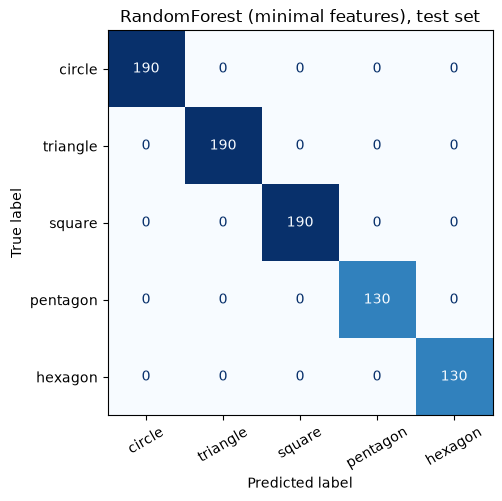

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

CLASSES = ["circle", "triangle", "square", "pentagon", "hexagon"]
feats = pd.read_csv("data/processed/features.csv")
X = np.load("data/processed/silhouettes_64.npz")["X"]

FULL = [c for c in feats.columns if c not in ("id", "label", "source", "split")]
REDUCED = ["hu1", "rect_fill", "circle_fill", "n_vertices_4",
           "rect_aspect", "area", "hu3", "solidity", "hu2"]
MINIMAL = ["n_vertices_4", "circle_fill", "rect_fill", "rect_aspect", "hu1"]
FEATSETS = {"full": FULL, "reduced": REDUCED, "minimal": MINIMAL}

models = {
    "LogReg": lambda: make_pipeline(StandardScaler(),
                                    LogisticRegression(max_iter=2000, class_weight="balanced")),
    "DecisionTree": lambda: DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=0),
    "KNN": lambda: make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7)),
    "SVM": lambda: make_pipeline(StandardScaler(), SVC(C=10, kernel="rbf", class_weight="balanced")),
    "RandomForest": lambda: RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=0),
}

# --- choose the model using CV results only ---
res = pd.read_csv("outputs/cv_results_by_source.csv")
res["f1_macro"] = res["accuracy"]   # accuracy: macro-F1 is distorted when a held-out source lacks classes
print(res.pivot(index="model", columns="features", values="f1_macro").round(4))
top = res.f1_macro.max()
best = res[res.f1_macro >= top - 0.002].sort_values(["n_features", "f1_macro"],
                                                    ascending=[True, False]).iloc[0]
fs = FEATSETS[best.features]
print(f"\nChosen: {best.model} on the {best.features} set ({len(fs)} features), CV F1 = {best.f1_macro:.4f}")

# --- one final evaluation on the test set ---
tr = feats[feats.split == "train"]
te = feats[feats.split == "test"].copy()
model = models[best.model]().fit(tr[fs], tr.label)
te["pred"] = model.predict(te[fs])

print("\nTest accuracy:", round(accuracy_score(te.label, te.pred), 4))
print("Test macro-F1:", round(f1_score(te.label, te.pred, average="macro"), 4))
print(classification_report(te.label, te.pred, labels=CLASSES, digits=3))

cm = confusion_matrix(te.label, te.pred, labels=CLASSES)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"{best.model} ({best.features} features), test set")
plt.xticks(rotation=30)
fig.savefig("outputs/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [3]:
te["correct"] = te.pred == te.label
print(te.groupby("source").correct.mean().round(4))
print(te.pivot_table(index="label", columns="source", values="correct", aggfunc="mean").round(3))

source
generated        1.0
kaggle_2d        1.0
kaggle_simple    1.0
Name: correct, dtype: float64
source    generated  kaggle_2d  kaggle_simple
label                                        
circle          1.0        1.0            1.0
hexagon         1.0        1.0            NaN
pentagon        1.0        1.0            NaN
square          1.0        1.0            1.0
triangle        1.0        1.0            1.0


0 errors


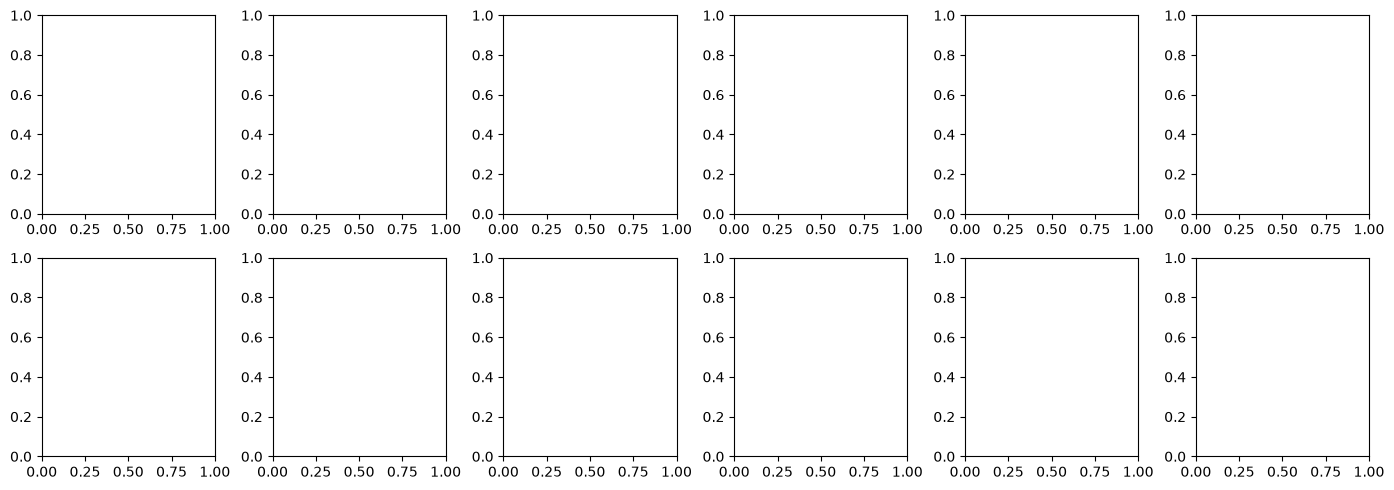

In [4]:
wrong = te[~te.correct]
print(len(wrong), "errors")
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax, (_, r) in zip(axes.ravel(), wrong.head(12).iterrows()):
    ax.imshow(X[int(r.id) - 1], cmap="gray")
    ax.set_title(f"true {r.label}\npred {r.pred}\n{r.source}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
fig.savefig("outputs/misclassified.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
rows = []
for src in ["generated", "kaggle_2d", "kaggle_simple"]:
    a = feats[(feats.source != src) & (feats.split == "train")]
    b = feats[feats.source == src]
    m = models[best.model]().fit(a[fs], a.label)
    p = m.predict(b[fs])
    rows.append({"held_out": src, "n": len(b),
                 "accuracy": accuracy_score(b.label, p),
                 "f1_macro": f1_score(b.label, p, labels=sorted(b.label.unique()), average="macro")})
robust = pd.DataFrame(rows)
print(robust.round(4))
robust.to_csv("outputs/leave_one_source_out.csv", index=False)

        held_out     n  accuracy  f1_macro
0      generated  1250    1.0000    1.0000
1      kaggle_2d  2000    1.0000    1.0000
2  kaggle_simple   900    0.9989    0.9994
